In [1]:
import numpy as np
import ase
from ase import Atoms
from ase import io
from ase.io.espresso import write_espresso_in as write_in
from ase.io.espresso import read_espresso_out as read_out
from ase.io.lammpsdata import write_lammps_data
from ase.io.lammpsdata import read_lammps_data
from ase.io.lammpsrun import read_lammps_dump_text
from ase.io import write
from ase.io import read
from ase.calculators.espresso import Espresso
from ase.build import surface
from ase.build import sort
from ase.constraints import FixAtoms
import csv
import os
import shutil
import pickle
import MDAnalysis as mda
import MDAnalysis.coordinates.XYZ
import random
import sys
import matplotlib
matplotlib.use("agg")
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from random import sample
from pylab import *
from matplotlib import rc

In [2]:
#unum = input("Enter the username: ")
snum = input("Enter the system considered: ")
itr = input("Enter the iteration number: ")
dr = ["Exploration", "Labelling"]
system = input("Enter the name for different system considered for Active learning separated by space: ").split()

Enter the system considered:  Pt
Enter the iteration number:  1
Enter the name for different system considered for Active learning separated by space:  bulk


In [3]:
# Creating All Directories
#base_dir = f"/scratch/{unum}/ActiveLearning_{snum}"
base_dir = f"../ActiveLearning_{snum}"

# Creating the main 'DP_models' directory
dp_model_path = os.path.join(base_dir, "DP_models")
if os.path.exists(dp_model_path):
    print(f"Directory already exists: {dp_model_path}")
else:
    os.makedirs(dp_model_path, exist_ok=True)
    print(f"Created new directory: {dp_model_path}")

# Creating system-specific directories
for system_name in system:
    # Creating the 'Training' directory for each system
    train_path = os.path.join(base_dir, system_name, "Training")
    if os.path.exists(train_path):
        print(f"Directory already exists: {train_path}")
    else:
        os.makedirs(train_path, exist_ok=True)
        print(f"Created new directory: {train_path}")

    # Creating the 'Exploration' and 'Labelling' directories for each system
    for sub_dir in dr:
        full_path = os.path.join(base_dir, system_name, sub_dir)
        if os.path.exists(full_path):
            print(f"Directory already exists: {full_path}")
        else:
            os.makedirs(full_path, exist_ok=True)
            print(f"Created new directory: {full_path}")

Directory already exists: ../ActiveLearning_Pt/DP_models
Directory already exists: ../ActiveLearning_Pt/bulk/Training
Directory already exists: ../ActiveLearning_Pt/bulk/Exploration
Directory already exists: ../ActiveLearning_Pt/bulk/Labelling


In [4]:
# Equal Temperature Range for Exploration and Labelling
#itr = input("Enter the iteration number:") Use this line for different iteration 
temp = [int(x) for x in input("Enter the temperature range considered for Active Learning seperated by space : ").split()]
for system_name in system:
    for sub_dir in dr:
        for temperature_value in temp: # Changed 'i' to 'temperature_value' for clarity
            full_path = os.path.join(base_dir, system_name, sub_dir, f"iter-{itr}",f"{temperature_value}K")
            if os.path.exists(full_path):
                print(f"Directory already exists: {full_path}")
            else:
                os.makedirs(full_path, exist_ok=True)
                print(f"Created new directory: {full_path}")

Enter the temperature range considered for Active Learning seperated by space :  300 400 500 600 700 800


Directory already exists: ../ActiveLearning_Pt/bulk/Exploration/iter-1/300K
Directory already exists: ../ActiveLearning_Pt/bulk/Exploration/iter-1/400K
Directory already exists: ../ActiveLearning_Pt/bulk/Exploration/iter-1/500K
Directory already exists: ../ActiveLearning_Pt/bulk/Exploration/iter-1/600K
Directory already exists: ../ActiveLearning_Pt/bulk/Exploration/iter-1/700K
Directory already exists: ../ActiveLearning_Pt/bulk/Exploration/iter-1/800K
Directory already exists: ../ActiveLearning_Pt/bulk/Labelling/iter-1/300K
Directory already exists: ../ActiveLearning_Pt/bulk/Labelling/iter-1/400K
Directory already exists: ../ActiveLearning_Pt/bulk/Labelling/iter-1/500K
Directory already exists: ../ActiveLearning_Pt/bulk/Labelling/iter-1/600K
Directory already exists: ../ActiveLearning_Pt/bulk/Labelling/iter-1/700K
Directory already exists: ../ActiveLearning_Pt/bulk/Labelling/iter-1/800K


In [5]:
# Creating .lmp and .data file using .xyz file
dirz = input("Enter the path for all system .xyz files separated by space: ").split()

# Check that the number of input files matches the number of systems
if len(dirz) != len(system):
    print("Error: The number of .xyz files does not match the number of systems. No files will be processed.")
else:
    # Process each file path, assuming order matches the 'systems' list
    for i in range(len(dirz)):
        xyz_file_path = dirz[i]
        system_name = system[i]

        try:
            # Read the atoms object from the first frame of the .xyz file
            atoms = read(xyz_file_path, index=-1)

            # Construct the target directory path for the current system
            system_dir_path = os.path.join(base_dir, system_name)

            # --- Check for .lmp file before writing ---
            lmp_file_path = os.path.join(system_dir_path, f"{system_name}.lmp")
            if os.path.exists(lmp_file_path):
                print(f"Skipping: .lmp file already exists at '{lmp_file_path}'")
            else:
                write(lmp_file_path, atoms, format='lammps-data')
                print(f"Successfully converted '{xyz_file_path}' to '{lmp_file_path}'")

            # --- Check for .data file before copying ---
            data_file_path = os.path.join(system_dir_path, f"{system_name}.data")
            if os.path.exists(data_file_path):
                print(f"Skipping: .data file already exists at '{data_file_path}'")
            else:
                shutil.copyfile(lmp_file_path, data_file_path)
                print(f"Successfully copied '{lmp_file_path}' to '{data_file_path}'")

        except FileNotFoundError:
            print(f"Error: The file '{lmp_file_path}' was not found. Skipping.")
        except Exception as e:
            print(f"An error occurred while processing '{lmp_file_path}': {e}")


Enter the path for all system .xyz files separated by space:  ../bulksupercell/bulk_Pt_supercell.extxyz


Skipping: .lmp file already exists at '../ActiveLearning_Pt/bulk/bulk.lmp'
Skipping: .data file already exists at '../ActiveLearning_Pt/bulk/bulk.data'


In [6]:
# Creating in.lammps and Lammps submission script

try:
    run_steps = int(input("Enter the total number of run steps (e.g., 2000000): "))
    timeout_str = input("Enter the timer timeout in H:MM:SS format (e.g., 23:55:00): ")

    # --- Automatically generate DeepMD graph files based on user input ---
    graph_num = int(input("Enter the number of DP models considered for training: "))
    script = input("Do you want the submission script for CPU or GPU version: ")
    
    # Define the base directory for all DP models
    base_dir = f"../ActiveLearning_{snum}"
    graph_dirz = os.path.join(base_dir, "DP_models")
    
    # Generate the list of graph file paths with the new subdirectory structure
    graph_files = []
    for i in range(graph_num):
        # Create the path for the numbered subdirectory
        numbered_subdir = os.path.join(graph_dirz, str(i + 1))
        
        # Ensure the subdirectory exists
        os.makedirs(numbered_subdir, exist_ok=True)
        print(f"Created directory: {numbered_subdir}")

        # Create the full file path for the graph
        file_path = os.path.join(numbered_subdir, f"graph{i+1}.pb")
        graph_files.append(file_path)

    # Print the generated file paths to confirm
    for path in graph_files:
        print(f"Generated graph file path: {path}")

    # You can now use the `graph_files` list later in your script
    # to reference each graph's specific file path.

except ValueError:
    print("Invalid input. Please enter valid numbers or use the correct format.")
    exit()

Enter the total number of run steps (e.g., 2000000):  200000
Enter the timer timeout in H:MM:SS format (e.g., 23:55:00):  03:00:00
Enter the number of DP models considered for training:  3
Do you want the submission script for CPU or GPU version:  GPU


Created directory: ../ActiveLearning_Pt/DP_models/1
Created directory: ../ActiveLearning_Pt/DP_models/2
Created directory: ../ActiveLearning_Pt/DP_models/3
Generated graph file path: ../ActiveLearning_Pt/DP_models/1/graph1.pb
Generated graph file path: ../ActiveLearning_Pt/DP_models/2/graph2.pb
Generated graph file path: ../ActiveLearning_Pt/DP_models/3/graph3.pb


In [7]:
import os

# Assuming 'base_dir', 'system', 'temp', 'itr', 'graph_files', etc. are already defined above.
command_width = 15

for system_name in system:
    # Construct the absolute path for the .lmp file once per system
    system_lmp_path = os.path.join(base_dir, system_name, f"{system_name}.lmp")

    # Define the directory where the submit script should live (The 'iter' folder)
    # We create this directory now so we can put the submit script in it
    system_iter_dir = os.path.join(base_dir, system_name, "Exploration", f"iter-{itr}")
    os.makedirs(system_iter_dir, exist_ok=True)

    # ------------------------------------------------------------------
    # BLOCK: Create submit_jobs.sh (Inside System Loop, Before Temp Loop)
    # ------------------------------------------------------------------
    submit_script_name = "submit_jobs.sh"
    submit_script_path = os.path.join(system_iter_dir, submit_script_name)
    
    # We use a raw string for the bash content
    submit_content = r"""#!/bin/bash

# This script finds all lmp.sub files inside this current directory (and subdirectories)
# and submits them to SLURM.

BASE_DIR="PLACEHOLDER_DIR"
TARGET_SUB="lmp.sub"

echo "Running in: $BASE_DIR"

# Find 'lmp.sub' recursively starting from the current directory
find "$BASE_DIR" -name "$TARGET_SUB" -print0 | while IFS= read -r -d '' sub_file; do
    
    # Get the directory where lmp.sub is located
    job_dir=$(dirname "$sub_file")
    
    echo "Found job in: $job_dir"
    
    # Enter directory
    cd "$job_dir" || continue
    
    # Submit the job
    sbatch "$TARGET_SUB"
    
    # Go back to previous folder silently
    cd - > /dev/null

done

echo "All jobs for this system submitted."
"""
    # Inject the specific path for this system into the bash script
    submit_content = submit_content.replace("PLACEHOLDER_DIR", system_iter_dir)

    try:
        with open(submit_script_path, "w") as f:
            f.write(submit_content)
        # Make the script executable
        os.chmod(submit_script_path, 0o755)
        print(f"--> Created submit script: {submit_script_path}")
    except IOError as e:
        print(f"Error creating submit script: {e}")
    # ------------------------------------------------------------------


    # Now we enter the Temperature loop
    for temperature_value in temp:
        
        # Construct the output filename and directory path for the specific temperature
        output_filename = "in.lammps"
        # This dir is inside the system_iter_dir we defined above
        output_dir = os.path.join(system_iter_dir, f"{temperature_value}K")
        output_file_path = os.path.join(output_dir, output_filename)

        os.makedirs(output_dir, exist_ok=True)

        # --- Generate in.lammps ---
        with open(output_file_path, 'w') as f:
            f.write(f"{'plugin load':<{command_width}} libdeepmd_lmp.so\n\n")
            f.write(f"{'units':<{command_width}} metal\n\n")
            f.write(f"{'boundary':<{command_width}} p p p\n\n")
            f.write(f"{'atom_style':<{command_width}} atomic\n\n")
            f.write(f"{'neighbor':<{command_width}} 2.0 bin\n\n")
            f.write(f"{'neigh_modify':<{command_width}} every 10 delay 0 check no\n\n")
            f.write(f"{'read_data':<{command_width}} {system_lmp_path}\n\n")

            f.write(f"{'mass':<{command_width}} 1 195.084\n\n")

            pair_style_components = ["pair_style", "deepmd", *graph_files]
            if graph_num > 1:
                pair_style_components.extend(["out_file", "md.out", "out_freq", "100"])
            
            pair_style_line = " ".join(pair_style_components)
            f.write(f"{pair_style_line}\n\n")
            
            f.write(f"{'pair_coeff':<{command_width}} * *\n\n")
            f.write(f"{'velocity':<{command_width}} all create {temperature_value} 12345678\n\n")
            f.write(f"{'fix':<{command_width}} 1 all nvt temp {temperature_value} {temperature_value} 0.1\n\n")
            f.write(f"{'timestep':<{command_width}} 0.0005\n\n")
            f.write(f"{'thermo_style':<{command_width}} custom step pe ke etotal temp press vol\n\n")
            f.write(f"{'thermo':<{command_width}} 100\n\n")
            f.write(f"{'dump':<{command_width}} 1 all dcd 100 {system_name}.dcd\n\n")
            f.write(f"{'timer timeout':<{command_width}} {timeout_str} every 100\n\n")
            f.write(f"{'run':<{command_width}} {run_steps}\n\n")
            f.write(f"{'write_restart':<{command_width}} lammps.restart\n")

        print(f"Successfully generated {output_file_path}")

        # --- Generate lmp.sub ---
        sub_filename = "lmp.sub"
        sub_file_path = os.path.join(output_dir, sub_filename)

        if script=='CPU':
            with open(sub_file_path, 'w') as f:
                f.write("#!/bin/bash\n")
                f.write(f"#SBATCH --job-name={system_name}_{temperature_value}K\n")
                f.write("#SBATCH --nodes=2\n")
                f.write("#SBATCH --ntasks-per-node=48\n")
                f.write("#SBATCH --partition=standard\n")
                f.write(f"#SBATCH --time={timeout_str}\n")
                f.write("export OMP_NUM_THREADS=2\n")
                f.write("mpirun -np 96 $HOME/.conda/envs/deepmd/bin/lmp -in in.lammps\n")
        else:
            with open(sub_file_path, 'w') as f:
                f.write("#!/bin/bash\n")
                f.write(f"#SBATCH --job-name={system_name}_{temperature_value}\n")
                f.write("#SBATCH --nodes=1\n")
                f.write(f"#SBATCH --ntasks-per-node=1\n")
                f.write("#SBATCH --gres=gpu:1\n")
                f.write("#SBATCH --partition=gpu\n")
                f.write(f"#SBATCH --time={timeout_str}\n")
                f.write("export OMP_NUM_THREADS=2\n")
                f.write("srun $HOME/.conda/envs/deepmd_gpu/bin/lmp -in in.lammps\n")
                
            
        print(f"Successfully generated {sub_file_path}")

--> Created submit script: ../ActiveLearning_Pt/bulk/Exploration/iter-1/submit_jobs.sh
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/300K/in.lammps
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/300K/lmp.sub
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/400K/in.lammps
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/400K/lmp.sub
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/500K/in.lammps
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/500K/lmp.sub
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/600K/in.lammps
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/600K/lmp.sub
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/700K/in.lammps
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/700K/lmp.sub
Successfully generated ../ActiveLearning_Pt/bulk/Exploration/iter-1/800K/in.lammps
Successful

In [8]:
for system_name in system:
    # Construct the absolute path for the .data file once per system
    system_data_path = os.path.join(base_dir, system_name, f"{system_name}.data")

    for current_temp in temp:
        dcd_path = os.path.join(base_dir, system_name, "Exploration", f"iter-{itr}", f"{current_temp}K", f"{system_name}.dcd")
    
        u = mda.Universe(system_data_path, dcd_path , format="LAMMPS", lengthunit="A", timeunit="ps", atom_style='id type x y z')
        
        type_to_element = {'1': 'Pt'}
        u.add_TopologyAttr('elements', [type_to_element[t] for t in u.atoms.types])
        elements_array = np.array([type_to_element[t] for t in u.atoms.types])
        
        xyz_output_path = os.path.join(base_dir, system_name, "Exploration", f"iter-{itr}", f"{current_temp}K", f"{system_name}.xyz")
        print(f"Starting to write {xyz_output_path}...")
    
        with open(xyz_output_path, 'w') as f:
            for ts in u.trajectory:
        
                cell_matrix = ts.triclinic_dimensions 
                matrix_str = " ".join([f"{val:.6f}" for val in cell_matrix.flatten()]) 
                comment_line = f"Lattice=\"{matrix_str}\" Properties=species:S:1:pos:R:3"
        
                f.write(f"{u.atoms.n_atoms}\n")
                f.write(f"{comment_line}\n")
                
                output_data = np.hstack((elements_array.reshape(-1, 1), ts.positions))
                
                np.savetxt(f, output_data, fmt='%s')
        
        print(f"Writing {xyz_output_path} complete.")

/home/cmel3/miniconda3/envs/myenv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Starting to write ../ActiveLearning_Pt/bulk/Exploration/iter-1/300K/bulk.xyz...
Writing ../ActiveLearning_Pt/bulk/Exploration/iter-1/300K/bulk.xyz complete.
Starting to write ../ActiveLearning_Pt/bulk/Exploration/iter-1/400K/bulk.xyz...
Writing ../ActiveLearning_Pt/bulk/Exploration/iter-1/400K/bulk.xyz complete.
Starting to write ../ActiveLearning_Pt/bulk/Exploration/iter-1/500K/bulk.xyz...
Writing ../ActiveLearning_Pt/bulk/Exploration/iter-1/500K/bulk.xyz complete.
Starting to write ../ActiveLearning_Pt/bulk/Exploration/iter-1/600K/bulk.xyz...
Writing ../ActiveLearning_Pt/bulk/Exploration/iter-1/600K/bulk.xyz complete.
Starting to write ../ActiveLearning_Pt/bulk/Exploration/iter-1/700K/bulk.xyz...
Writing ../ActiveLearning_Pt/bulk/Exploration/iter-1/700K/bulk.xyz complete.
Starting to write ../ActiveLearning_Pt/bulk/Exploration/iter-1/800K/bulk.xyz...
Writing ../ActiveLearning_Pt/bulk/Exploration/iter-1/800K/bulk.xyz complete.


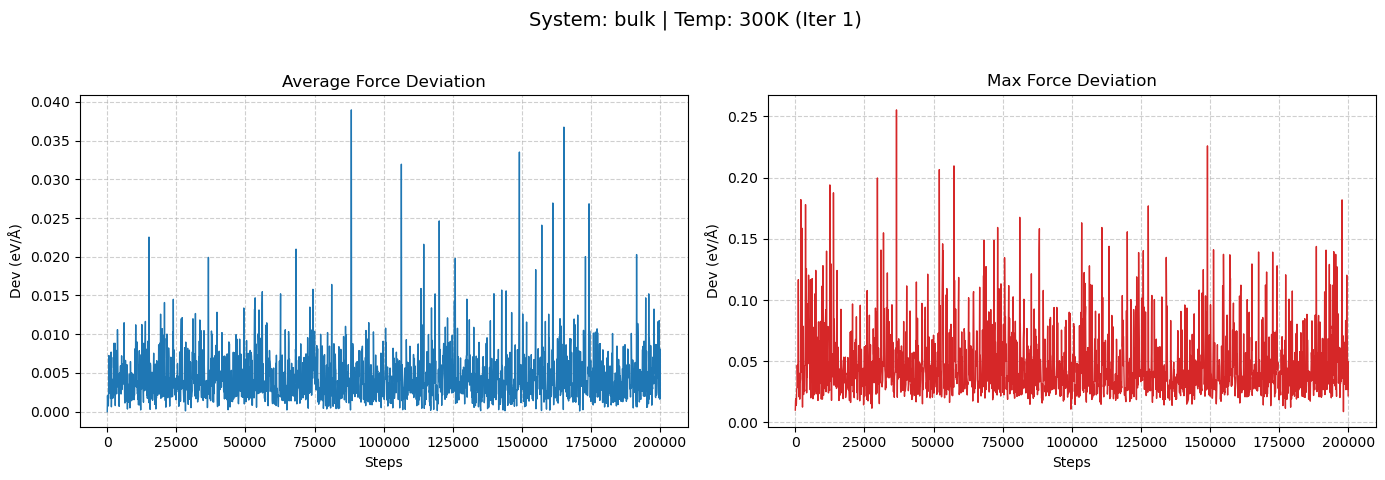

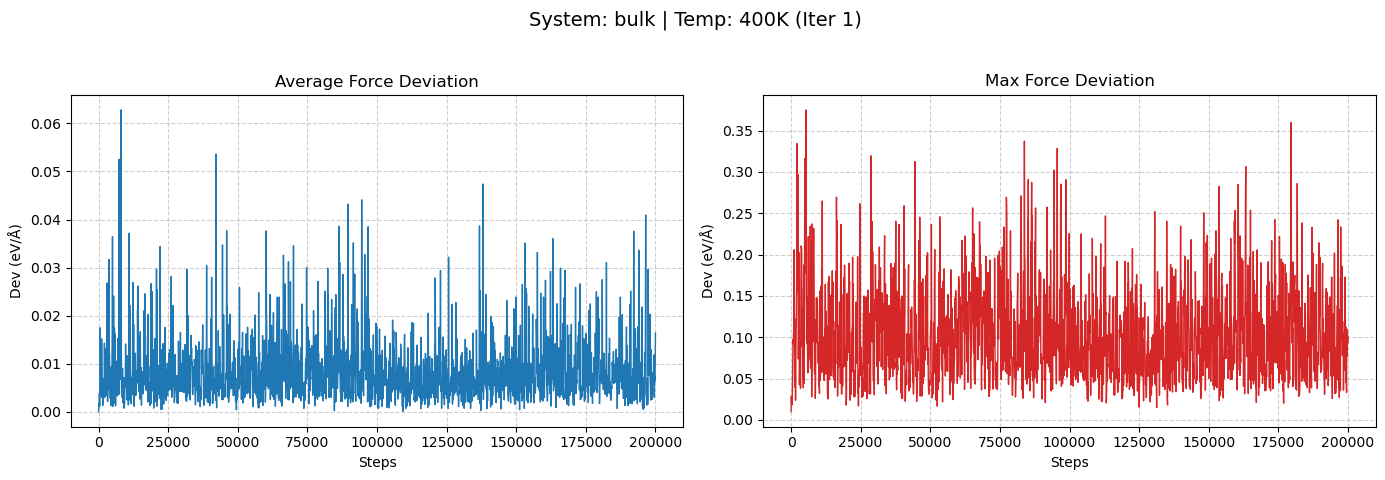

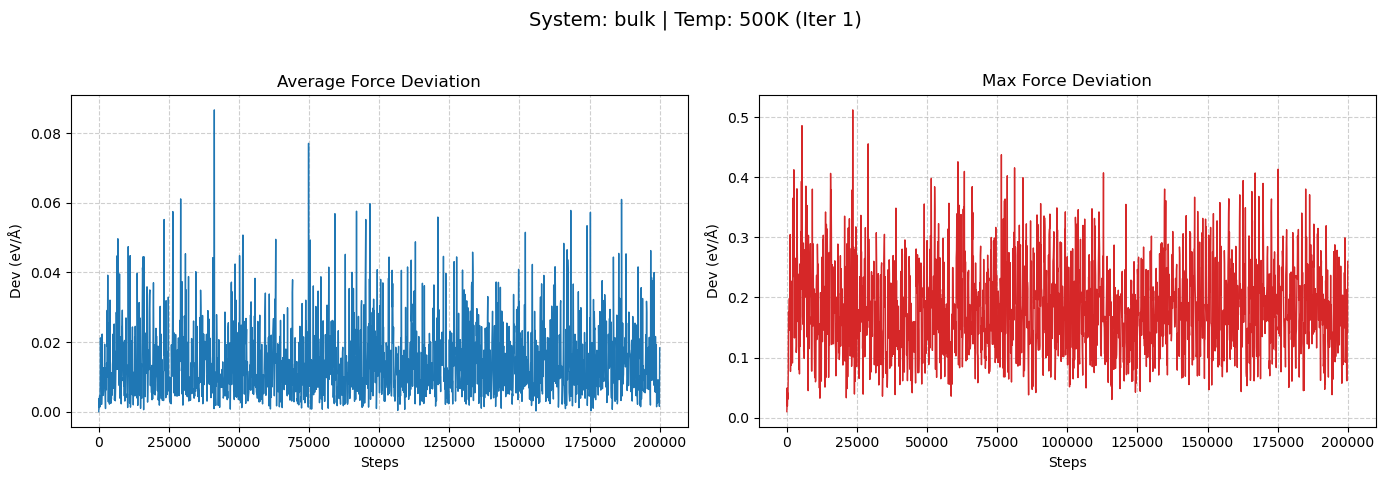

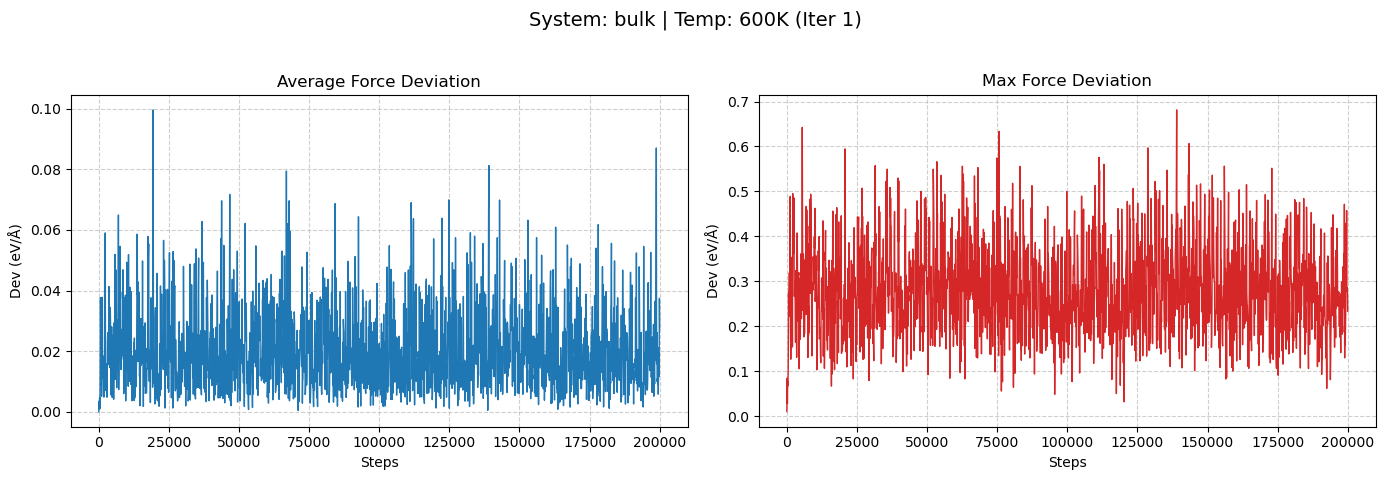

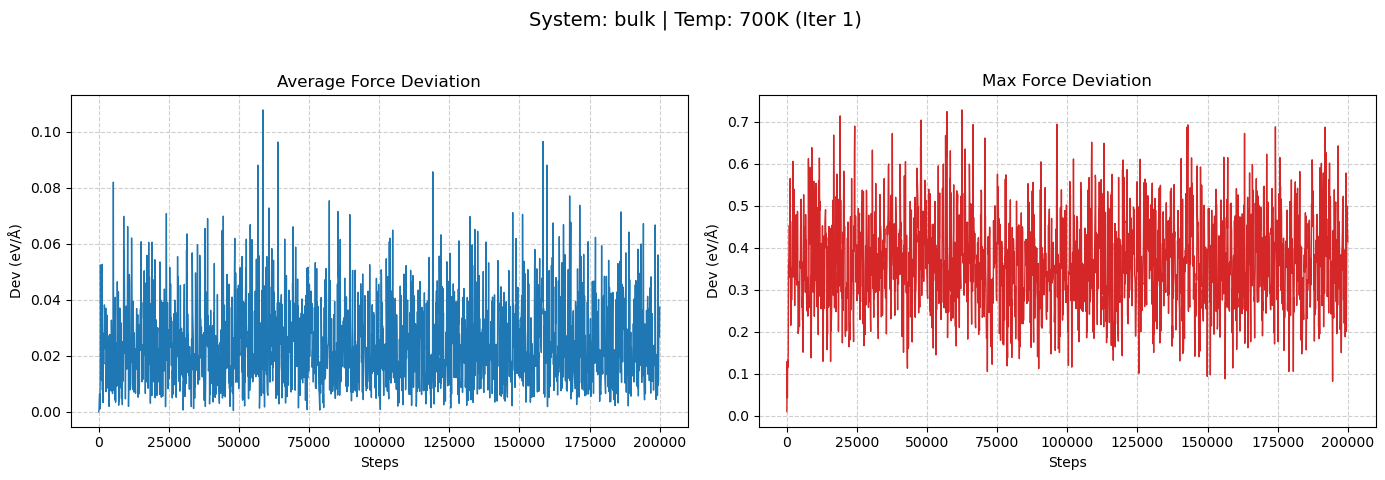

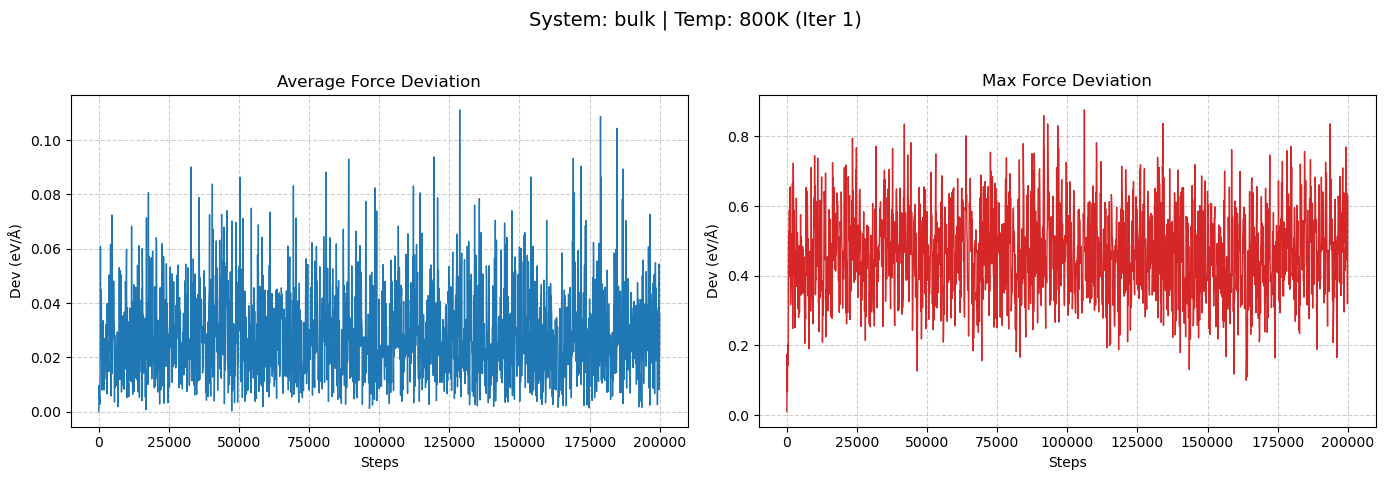

In [9]:
import os
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt

# Ensure plots show up in your notebook
%matplotlib inline

# --- USER CONFIGURATION ---                         

for system_name in system:
    system_data_path = os.path.join(base_dir, system_name, f"{system_name}.data")
    
    for current_temp in temp:
        # 1. SETUP PATHS
        temp_dir = os.path.join(base_dir, system_name, "Exploration", f"iter-{itr}", f"{current_temp}K")
        dev_file = os.path.join(temp_dir, "md.out")

        # 2. SIDE-BY-SIDE PLOTTING
        try:
     
            data = np.loadtxt(dev_file)
            steps = data[:, 0]
            f_max = data[:, 1]
            f_avg = data[:, 2]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            fig.suptitle(f'System: {system_name} | Temp: {current_temp}K (Iter {itr})', fontsize=14)

            # Left Plot: Average Deviation
            ax1.plot(steps, f_avg, color='tab:blue', linewidth=1)
            ax1.set_title('Average Force Deviation')
            ax1.set_xlabel('Steps')
            ax1.set_ylabel('Dev (eV/Å)')
            ax1.grid(True, linestyle='--', alpha=0.6)

            # Right Plot: Max Deviation
            ax2.plot(steps, f_max, color='tab:red', linewidth=1)
            ax2.set_title('Max Force Deviation')
            ax2.set_xlabel('Steps')
            ax2.set_ylabel('Dev (eV/Å)')
            ax2.grid(True, linestyle='--', alpha=0.6)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit the suptitle
            
            # Save the dual plot
            plt.savefig(os.path.join(temp_dir, f"side_by_side_dev.png"), dpi=150)
            plt.show()
            plt.close()
            
        except Exception as e:
            print(f"Could not plot deviations for {current_temp}K: {e}")


In [10]:
import random
import os
import sys
import numpy as np
from ase.io import read, write
      
pseudo_dir = "/scratch/ch24d003/pseudo"

# =============================================================================
# MAIN SCRIPT
# =============================================================================
if __name__ == "__main__":
    try:
        val = input("Enter number of configs to generate per temp: ")
        SampleSize = int(val)
    except ValueError:
        print("Invalid input.")
        sys.exit()

    for system_name in system:
        print(f"--- Generating Inputs for {system_name} ---")
        
        explor_path = os.path.join(base_dir, system_name, 'Exploration', f'iter-{itr}')
        label_path = os.path.join(base_dir, system_name, 'Labelling', f'iter-{itr}')
        os.makedirs(label_path, exist_ok=True)

        for temperature_value in temp:
            output_dir_explor = os.path.join(explor_path, f'{temperature_value}K')
            output_dir_label = os.path.join(label_path, f'{temperature_value}K')
            
            md_path = os.path.join(output_dir_explor, 'md.out')
            xyz_path = os.path.join(output_dir_explor, f'{system_name}.xyz')

            if not os.path.exists(md_path) or not os.path.exists(xyz_path):
                print(f"  [Skip] Files missing for {temperature_value}K")
                continue

            # Parse MD deviations
            max_dev_f = []
            try:
                with open(md_path, 'r') as f:
                    for line in f.readlines()[1:]:
                        parts = line.split()
                        if len(parts) >= 5:
                            try: max_dev_f.append(float(parts[4]))
                            except: pass
            except Exception: continue

            # Select frames
            config_idx_all = [j for j, d in enumerate(max_dev_f) if 0.20 <= d <= 0.80]
            if len(config_idx_all) >= SampleSize:
                config_idx = random.sample(config_idx_all, SampleSize)
            else:
                config_idx = config_idx_all

            if not config_idx: continue

            # Read Trajectory
            full_traj = read(xyz_path, index=':')
            atoms_ref = full_traj[0]
            ntyp = len(set(atoms_ref.get_chemical_symbols()))
            nat = len(atoms_ref)

            # QE Setup
            pseudos = {'Pt': 'Pt_ONCV_PBE-1.2.upf'}
            input_qe = {
            'control': {
                'calculation': 'scf',
                'outdir': './outdir',
                'pseudo_dir': pseudo_dir,
                'tprnfor': True,
                'disk_io': 'none',
                'restart_mode': 'from_scratch',
            },
            'system': {
                'ibrav': 0,
                'ntyp': ntyp,
                'nat': nat,
                'ecutwfc': 70,
                'ecutrho': 280,
                'input_dft': 'PBE',
                'nbnd': 346,
                'occupations': 'smearing', 
                'smearing': 'marzari-vanderbilt',
                'degauss': 0.02,
            },
            'electrons': {
                'mixing_beta': 0.1,
                'electron_maxstep': 200,
                'diagonalization': 'david',
                'conv_thr': 1e-06,
                'mixing_ndim': 8,
            },
        }

            print(f"  -> Creating {len(config_idx)} jobs for {temperature_value}K")

            # Loop to create Individual Folders
            for k_idx, k_frame in enumerate(config_idx):
                output_subdir = os.path.join(output_dir_label, f'scf_{k_idx}')
                os.makedirs(output_subdir, exist_ok=True)
                
                # Write pw.in
                write(os.path.join(output_subdir, 'pw.in'), full_traj[k_frame], format='espresso-in', 
                      input_data=input_qe, pseudopotentials=pseudos, kpts=(4,4,4), koffset=(0,0,0))
                
                # Write qe.sub (Individual)
                with open(os.path.join(output_subdir, 'qe.sub'), 'w') as f:
                    f.write("#!/bin/bash\n")
                    f.write(f"#SBATCH --job-name={system_name}_{temperature_value}_{k_idx}\n")
                    f.write("#SBATCH --nodes=2\n#SBATCH --ntasks-per-node=48\n#SBATCH --partition=standard\n")
                    f.write("#SBATCH --time=02:00:00\n#SBATCH --mail-type=end\n")
                    f.write("mpirun -np 96 -mca coll_hcoll_enable 0 $HOME/qe-6.7/bin/pw.x -in pw.in > pw.out\n")
                    f.write("rm -r outdir\n")

            # --- Temp-level loop script ---
            t_script = os.path.join(output_dir_label, "submit_individual_jobs.sh")
            with open(t_script, "w") as f:
                f.write("#!/bin/bash\nfor dir in scf_*; do\n  [ -d \"$dir\" ] && cd \"$dir\" && [ -f \"qe.sub\" ] && sbatch qe.sub && cd ..\ndone\n")
            os.chmod(t_script, 0o755)

            # --- NEW: Create Backup Array Script ---
            # This creates a single SLURM script that runs all jobs in this folder as an array
            array_script_path = os.path.join(output_dir_label, 'qe_array.sub')
            num_tasks = len(config_idx)
            array_range = f"0-{num_tasks - 1}"
            
            with open(array_script_path, 'w') as f:
                f.write("#!/bin/bash\n")
                f.write(f"#SBATCH --job-name={system_name}_{temperature_value}_ARR\n")
                f.write("#SBATCH --nodes=2\n")
                f.write("#SBATCH --ntasks-per-node=48\n")
                f.write("#SBATCH --partition=standard\n")
                f.write("#SBATCH --time=02:00:00\n")
                f.write(f"#SBATCH --array={array_range}\n\n")
                
                # Dynamic directory change based on Array ID
                f.write("# Move to the specific folder for this task ID\n")
                f.write("cd $SLURM_SUBMIT_DIR/scf_$SLURM_ARRAY_TASK_ID\n\n")
                
                f.write("mpirun -np 96 -mca coll_hcoll_enable 0 $HOME/qe-6.7/bin/pw.x -in pw.in > pw.out\n")
                f.write("rm -r outdir\n")
            
            print(f"     [Backup] Created array script: {array_script_path}")

        # Master submit script
        m_script = os.path.join(label_path, "submit_master.sh")
        with open(m_script, "w") as f:
            f.write(f"#!/bin/bash\nfind \"{label_path}\" -name \"submit_individual_jobs.sh\" -execdir ./{{}} \\;\n")
        os.chmod(m_script, 0o755)
        print(f"Done. Run this to submit individual jobs: {m_script}")
        print(f"OR go to specific temp folders and run 'sbatch qe_array.sub'")

Enter number of configs to generate per temp:  100


--- Generating Inputs for bulk ---
  -> Creating 100 jobs for 300K
     [Backup] Created array script: ../ActiveLearning_Pt/bulk/Labelling/iter-1/300K/qe_array.sub
  -> Creating 100 jobs for 400K
     [Backup] Created array script: ../ActiveLearning_Pt/bulk/Labelling/iter-1/400K/qe_array.sub
  -> Creating 100 jobs for 500K
     [Backup] Created array script: ../ActiveLearning_Pt/bulk/Labelling/iter-1/500K/qe_array.sub
  -> Creating 46 jobs for 600K
     [Backup] Created array script: ../ActiveLearning_Pt/bulk/Labelling/iter-1/600K/qe_array.sub
  -> Creating 7 jobs for 700K
     [Backup] Created array script: ../ActiveLearning_Pt/bulk/Labelling/iter-1/700K/qe_array.sub
  -> Creating 3 jobs for 800K
     [Backup] Created array script: ../ActiveLearning_Pt/bulk/Labelling/iter-1/800K/qe_array.sub
Done. Run this to submit individual jobs: ../ActiveLearning_Pt/bulk/Labelling/iter-1/submit_master.sh
OR go to specific temp folders and run 'sbatch qe_array.sub'


In [11]:
import os
import sys
import numpy as np
from ase.io import read

# =============================================================================
# HELPER: Get Expected Atom Count
# =============================================================================
def get_expected_atoms(system_base_dir, sys_name, iter_num):
    # Try 1: type.raw
    type_raw = os.path.join(system_base_dir, sys_name, 'Training', 'type.raw')
    if os.path.exists(type_raw):
        try:
            with open(type_raw, 'r') as f:
                return len(f.read().strip().split())
        except: pass

    # Try 2: Reference XYZ
    explo_path = os.path.join(system_base_dir, sys_name, 'Exploration', f'iter-{iter_num}')
    if os.path.exists(explo_path):
        subdirs = [d for d in os.listdir(explo_path) if os.path.isdir(os.path.join(explo_path, d))]
        if subdirs:
            ref_xyz = os.path.join(explo_path, subdirs[0], f'{sys_name}.xyz')
            if os.path.exists(ref_xyz):
                try: return len(read(ref_xyz))
                except: pass
    return None

# =============================================================================
# HELPER: Validate Calculation
# =============================================================================
def validate_calculation(conf, expected_atoms):
    """
    Checks ALL properties. Returns (True, "") if good, or (False, Reason) if bad.
    """
    # 1. Check Atom Count
    if expected_atoms and len(conf) != expected_atoms:
        return False, f"Wrong Atom Count: Found {len(conf)}, Expected {expected_atoms}"

    # 2. Check Energy
    try:
        e = conf.get_potential_energy()
        if e is None: return False, "Missing Energy"
    except:
        return False, "Energy Error"

    # 3. Check Forces
    try:
        f = conf.get_forces()
        if f is None: return False, "Missing Forces"
        if f.shape != (len(conf), 3): return False, "Malformed Forces"
    except:
        return False, "Force Error"

    # 4. Check Coordinates (Positions)
    try:
        p = conf.get_positions()
        if p is None: return False, "Missing Coords"
        if p.shape != (len(conf), 3): return False, "Malformed Coords"
    except:
        return False, "Coord Error"

    # 5. Check Box (Cell)
    try:
        c = conf.get_cell()
        if c is None: return False, "Missing Box"
        if np.prod(c.shape) < 3: return False, "Malformed Box"
    except:
        return False, "Box Error"

    return True, "OK"

# =============================================================================
# MAIN SCRIPT
# =============================================================================
if __name__ == "__main__":
    print("\n=== STARTING FULL INTEGRITY DIAGNOSTIC (VERBOSE) ===\n")

    for system_name in system:
        expected_atoms = get_expected_atoms(base_dir, system_name, itr)
        
        if expected_atoms is None:
            print(f"⚠️  WARNING: Could not determine expected atom count for {system_name}.")
            
        print(f"--- Checking {system_name} (Expect ~{expected_atoms} atoms) ---")

        # Detailed Counters
        total_good = 0
        total_missing = 0
        total_empty = 0
        total_invalid = 0  # Failed validation (wrong atoms, no forces, etc)
        total_crash = 0    # ASE couldn't read file

        for temperature_value in temp:
            label_dir = os.path.join(base_dir, system_name, 'Labelling', f'iter-{itr}', f'{temperature_value}K')
            
            if not os.path.exists(label_dir):
                continue

            scf_folders = [d for d in os.listdir(label_dir) if d.startswith("scf_")]
            try: scf_folders.sort(key=lambda x: int(x.split('_')[1]))
            except: pass 

            for folder in scf_folders:
                file_path = os.path.join(label_dir, folder, 'pw.out')

                # 1. Check Existence
                if not os.path.exists(file_path):
                    print(f"  [MISSING] {temperature_value}K / {folder}")
                    total_missing += 1
                    continue

                # 2. Check Empty
                if os.path.getsize(file_path) == 0:
                    print(f"  [EMPTY]   {temperature_value}K / {folder} is 0 bytes.")
                    total_empty += 1
                    continue

                # 3. Check Content Integrity
                try:
                    conf = read(file_path, format='espresso-out')
                    
                    is_valid, message = validate_calculation(conf, expected_atoms)
                    
                    if is_valid:
                        total_good += 1
                    else:
                        print(f"  [FAIL]    {temperature_value}K / {folder}: {message}")
                        total_invalid += 1

                except Exception as e:
                    print(f"  [CRASH]   {temperature_value}K / {folder}: Unreadable ({e})")
                    total_crash += 1

        print("-" * 40)
        print(f"SUMMARY FOR {system_name}:")
        print(f"  ✅ Good Data:       {total_good}")
        print(f"  ❌ Validation Fail: {total_invalid} (Wrong atoms, no forces, etc.)")
        print(f"  ❌ Empty Files:     {total_empty}")
        print(f"  ❌ Missing Files:   {total_missing}")
        print(f"  ❌ Read Crashes:    {total_crash}")
        print("-" * 40)


=== STARTING FULL INTEGRITY DIAGNOSTIC (VERBOSE) ===

--- Checking bulk (Expect ~32 atoms) ---
  [CRASH]   300K / scf_1: Unreadable ()
----------------------------------------
SUMMARY FOR bulk:
  ✅ Good Data:       355
  ❌ Validation Fail: 0 (Wrong atoms, no forces, etc.)
  ❌ Empty Files:     0
  ❌ Missing Files:   0
  ❌ Read Crashes:    1
----------------------------------------


In [16]:
import os
import sys
import numpy as np
from ase.io import read

# =============================================================================
# HELPER: Get Expected Atom Count
# =============================================================================
def get_expected_atoms(system_base_dir, sys_name, iter_num):
    type_raw = os.path.join(system_base_dir, sys_name, 'Training', 'type.raw')
    if os.path.exists(type_raw):
        try:
            with open(type_raw, 'r') as f:
                return len(f.read().strip().split())
        except: pass

    explo_path = os.path.join(system_base_dir, sys_name, 'Exploration', f'iter-{iter_num}')
    if os.path.exists(explo_path):
        subdirs = [d for d in os.listdir(explo_path) if os.path.isdir(os.path.join(explo_path, d))]
        if subdirs:
            ref_xyz = os.path.join(explo_path, subdirs[0], f'{sys_name}.xyz')
            if os.path.exists(ref_xyz):
                try: return len(read(ref_xyz))
                except: pass
    return None

# =============================================================================
# MAIN SCRIPT
# =============================================================================
if __name__ == "__main__":
    
    total_reruns = 0
    
    for system_name in system:
        print(f"--- Processing {system_name} ---")
        
        expected_atoms = get_expected_atoms(base_dir, system_name, itr)
        if expected_atoms:
            print(f"   (Auto-detected atom count: {expected_atoms})")

        label_base_path = os.path.join(base_dir, system_name, 'Labelling', f'iter-{itr}')
        rerun_script_path = os.path.join(label_base_path, "submit_reruns.sh")
        
        with open(rerun_script_path, "w") as f_sh:
            f_sh.write("#!/bin/bash\n")
            f_sh.write(f"# Auto-generated rerun script for {system_name}\n")
            f_sh.write("echo 'Starting reruns...'\n\n")

            for temperature_value in temp:
                label_dir = os.path.join(label_base_path, f'{temperature_value}K')
                if not os.path.exists(label_dir): continue

                scf_folders = [d for d in os.listdir(label_dir) if d.startswith("scf_")]
                try: scf_folders.sort(key=lambda x: int(x.split('_')[1]))
                except: pass 

                rerun_count_temp = 0

                for folder in scf_folders:
                    folder_path = os.path.join(label_dir, folder)
                    file_path = os.path.join(folder_path, 'pw.out')
                    
                    needs_rerun = False
                    reason = ""

                    # 1. Basic File Checks
                    if not os.path.exists(file_path):
                        needs_rerun = True; reason = "Missing pw.out"
                    elif os.path.getsize(file_path) == 0:
                        needs_rerun = True; reason = "Empty pw.out"
                    else:
                        # 2. Deep Integrity Checks
                        try:
                            conf = read(file_path, format='espresso-out')
                            
                            # Check A: Atom Count
                            if expected_atoms and len(conf) != expected_atoms:
                                needs_rerun = True
                                reason = f"Count mismatch ({len(conf)} vs {expected_atoms})"
                            
                            # Check B: Energy
                            elif conf.get_potential_energy() is None:
                                needs_rerun = True; reason = "Missing Energy"
                                
                            # Check C: Forces (Existence & Shape)
                            elif conf.get_forces() is None:
                                needs_rerun = True; reason = "Missing Forces"
                            elif conf.get_forces().shape != (len(conf), 3):
                                needs_rerun = True; reason = "Malformed Forces"
                                
                            # Check D: Coords (Existence & Shape)
                            elif conf.get_positions() is None:
                                needs_rerun = True; reason = "Missing Coords"
                            elif conf.get_positions().shape != (len(conf), 3):
                                needs_rerun = True; reason = "Malformed Coords"

                            # Check E: Box/Cell
                            elif conf.get_cell() is None:
                                needs_rerun = True; reason = "Missing Box"

                        except Exception:
                            needs_rerun = True; reason = "Corrupt/Unreadable"

                    if needs_rerun:
                        f_sh.write(f"# {temperature_value}K / {folder}: {reason}\n")
                        f_sh.write(f"cd \"{folder_path}\" && sbatch qe.sub\n")
                        rerun_count_temp += 1
                        total_reruns += 1

                if rerun_count_temp > 0:
                    print(f"  {temperature_value}K: Added {rerun_count_temp} jobs.")

            f_sh.write("\necho 'All rerun jobs submitted.'\n")
        
        os.chmod(rerun_script_path, 0o755)
        print(f"Created rerun script at: {rerun_script_path}")

    print("-------------------------------------------------------")
    print(f"Total jobs scheduled for rerun: {total_reruns}")

--- Processing bulk ---
   (Auto-detected atom count: 32)
  300K: Added 1 jobs.
Created rerun script at: ../ActiveLearning_Pt/bulk/Labelling/iter-1/submit_reruns.sh
-------------------------------------------------------
Total jobs scheduled for rerun: 1


In [14]:
import os
import sys
import numpy as np
from ase.io import read

element_mapping = {'Pt': 0}

# =============================================================================
# MAIN SCRIPT
# =============================================================================
if __name__ == "__main__":

    for system_name in system:
        print(f"--- Collecting Data for {system_name} ---")

        train_path = os.path.join(base_dir, system_name, 'Training')
        os.makedirs(train_path, exist_ok=True)
        
        # 1. Create type.raw and type.map from reference
        try:
            # --- START OF ADDED type.map PART ---
            sorted_elements = sorted(element_mapping.items(), key=lambda x: x[1])
            with open(os.path.join(train_path, "type.map"), "w") as f_map:
                for symbol, index in sorted_elements:
                    f_map.write(f"{symbol}\n")
            print("  -> type.map written.")
            # --- END OF ADDED type.map PART ---

            # We look for a reference file in the first available temperature folder
            ref_path = os.path.join(base_dir, system_name, 'Exploration', f'iter-{itr}', f'{temp[0]}K', f'{system_name}.xyz')
            
            if os.path.exists(ref_path):
                atoms = read(ref_path, index=0)
                # This line was failing because element_mapping wasn't defined
                types = [str(element_mapping.get(s, -1)) for s in atoms.get_chemical_symbols()]
                
                with open(os.path.join(train_path, "type.raw"), "w") as f:
                    f.write(" ".join(types) + "\n")
                print("  -> type.raw written.")
            else:
                print(f"  [Warning] Reference file not found at {ref_path}. type.raw NOT created.")
        except Exception as e:
            print(f"  [Error] type.raw creation failed: {e}")

        # 2. Append Data
        total_c = 0
        
        # Open all files in append mode
        with open(os.path.join(train_path, "coord.raw"), "a") as f_coord, \
             open(os.path.join(train_path, "energy.raw"), "a") as f_energy, \
             open(os.path.join(train_path, "force.raw"), "a") as f_force, \
             open(os.path.join(train_path, "box.raw"), "a") as f_box:

            for temperature_value in temp:
                label_dir = os.path.join(base_dir, system_name, 'Labelling', f'iter-{itr}', f'{temperature_value}K')
                if not os.path.exists(label_dir): 
                    continue

                # Get folders sorted numerically
                scf_folders = [d for d in os.listdir(label_dir) if d.startswith("scf_")]
                try: 
                    scf_folders.sort(key=lambda x: int(x.split('_')[1]))
                except: 
                    pass

                c_temp = 0
                for folder in scf_folders:
                    file_path = os.path.join(label_dir, folder, 'pw.out')

                    # Skip invalid files quietly (file missing or empty)
                    if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
                        continue

                    try:
                        # Parse output
                        conf = read(file_path, format='espresso-out')
                        
                        # Only write if forces exist (converged)
                        if conf.get_forces() is not None:
                            f_coord.write(' '.join(conf.get_positions().flatten().astype('str').tolist()) + '\n')
                            f_energy.write(str(conf.get_potential_energy()) + '\n')
                            f_force.write(' '.join(conf.get_forces().flatten().astype('str').tolist()) + '\n')
                            f_box.write(' '.join(conf.get_cell().flatten().astype('str').tolist()) + '\n')
                            c_temp += 1 
                            f.write(f"#SBATCH --mail-user={unum}@smail.iitm.ac.in\n\n")
                    except Exception:
                        continue
                
                print(f"  -> {temperature_value}K: Appended {c_temp} configs.")
                total_c += c_temp

        print(f"*** TOTAL COLLECTED: {total_c} configurations added to Training. ***\n")

--- Collecting Data for bulk ---
  -> type.map written.
  -> type.raw written.
  -> 300K: Appended 99 configs.
  -> 400K: Appended 100 configs.
  -> 500K: Appended 100 configs.
  -> 600K: Appended 46 configs.
  -> 700K: Appended 7 configs.
  -> 800K: Appended 3 configs.
*** TOTAL COLLECTED: 355 configurations added to Training. ***

